# Ridge Regression (RR) on MHAR Feature Set

**Purpose:** This notebook implements the Ridge Regression (RR) model of Hoerl and Kennard (1970) 
on the MHAR feature set for the EURO STOXX 50 index over the period 1999–2020, 
following the methodology of Christensen, Siggaard, and Veliyev (2023). Ridge 
Regression extends the baseline HAR model by adding an L2 penalty term to the 
ordinary least squares objective function, shrinking all coefficient estimates toward 
zero to reduce overfitting and improve out-of-sample forecast accuracy. The 
regularization strength $\lambda$ is tuned in the validation set following the 
paper's approach. We adopt the same rolling window estimation scheme as the HAR 
model, ensuring a direct apples-to-apples comparison across models.

## 1. Imports

We import the necessary libraries for data handling, numerical computation, and 
model estimation. We use $\texttt{scikit-learn}$ for the Ridge Regression 
implementation, which provides an efficient closed-form solution via the normal 
equations. Random seeds are set to ensure reproducibility of results.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully
NumPy version: 1.26.4
Pandas version: 2.2.3


## 2. Data Loading

We load the MALL dataset which contains all predictor variables and the target 
variable $RV_{t+1}$ for the EURO STOXX 50 index over the period 1999–2020. 
The target variable RV\_target represents next day's realized variance $RV_{t+1}$, 
already constructed and saved in the MALL dataset.

In [8]:
# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()

Shape: (5488, 30)
Date range: 1999-01-05 to 2020-08-05
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,CISS,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000078,0.000093,0.000129,-9.462355,-9.288024,-8.958306,0.000046,0.000032,0.000000,-0.000682,...,0.2085,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000058
1999-01-06,0.000058,0.000092,0.000123,-9.760055,-9.290171,-9.005038,0.000043,0.000014,0.000000,-0.000682,...,0.2214,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000139
1999-01-07,0.000139,0.000102,0.000121,-8.877543,-9.192627,-9.023153,0.000072,0.000068,-0.015530,-0.003788,...,0.2254,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000108
1999-01-08,0.000108,0.000106,0.000112,-9.130603,-9.148418,-9.097084,0.000055,0.000053,-0.003409,-0.003788,...,0.2297,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000166
1999-01-11,0.000166,0.000110,0.000110,-8.702667,-9.116188,-9.115384,0.000076,0.000090,-0.019561,-0.007700,...,0.2583,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000115


## 3. Data Split
### 3.1 Train / Validation / Test Split (70 / 10 / 20)

Following Christensen et al. (2023), we split the sample into a training set 
(70%), validation set (10%), and test set (20%). Unlike the HAR model where 
the training and validation sets are merged for rolling window estimation, here 
we keep them separate since the validation set is used exclusively for tuning 
the regularization hyperparameter $\lambda$. The test set is reserved exclusively 
for out-of-sample evaluation and no estimation or tuning is conducted on it. 
This split is identical to all other model implementations, ensuring a fair 
comparison across models.

In [12]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

print(f"Total observations: {n}")
print(f"\nTrain:      {MALL.index[0].date()} to {MALL.index[n_train-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {MALL.index[n_train].date()} to {MALL.index[n_train+n_val-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {MALL.index[n_train+n_val].date()} to {MALL.index[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")

Total observations: 5488

Train:      1999-01-05 to 2014-02-25 (3841 obs, 70.0%)
Validation: 2014-02-26 to 2016-04-19 (548 obs, 10.0%)
Test:       2016-04-20 to 2020-08-05 (1099 obs, 20.0%)


## 4. Feature Set Construction and Standardization

### 4.1 MHAR Feature Set

We use the MHAR feature set consisting of the three standard HAR predictors: 
daily (RVD), weekly (RVW), and monthly (RVM) realized variance. Following 
Christensen et al. (2023), all inputs are standardized by subtracting the 
training set mean and dividing by the training set standard deviation prior 
to estimation. This is particularly important for Ridge Regression since the 
L2 penalty is sensitive to the scale of the input variables — without 
standardization, variables with larger scales would be penalized more heavily 
than variables with smaller scales, introducing an undesirable bias in the 
shrinkage. Standardization parameters are computed exclusively from the 
training set and applied consistently across the full dataset, ensuring no 
look-ahead bias is introduced.

In [15]:
# Define target and MHAR feature set
y      = MALL["RV_target"].values
X_MHAR = MALL[["RVD", "RVW", "RVM"]].values

# Split into train, validation and test sets
X_train = X_MHAR[:n_train]
X_val   = X_MHAR[n_train:n_train + n_val]
X_test  = X_MHAR[n_train + n_val:]

y_train = y[:n_train]
y_val   = y[n_train:n_train + n_val]
y_test  = y[n_train + n_val:]

# Compute standardization parameters from training set only
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

# Scale full dataset using training set parameters
X_scaled = (X_MHAR - X_mean) / X_std

# Store scaled splits for verification
X_train_scaled = X_scaled[:n_train]
X_val_scaled   = X_scaled[n_train:n_train + n_val]
X_test_scaled  = X_scaled[n_train + n_val:]

print(f"Feature set: RVD, RVW, RVM")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y.shape}")
print(f"Training set:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_scaled.shape},   y={y_val.shape}")
print(f"Test set:       X={X_test_scaled.shape},  y={y_test.shape}")
print(f"\nStandardization parameters from training set:")
print(f"  X mean: {X_mean}")
print(f"  X std:  {X_std}")
print(f"\nVerification — training set after standardization:")
print(f"  X mean (should be ~0): {X_train_scaled.mean(axis=0).round(6)}")
print(f"  X std  (should be ~1): {X_train_scaled.std(axis=0).round(6)}")

Feature set: RVD, RVW, RVM

Full dataset:   X=(5488, 3), y=(5488,)
Training set:   X=(3841, 3), y=(3841,)
Validation set: X=(548, 3),   y=(548,)
Test set:       X=(1099, 3),  y=(1099,)

Standardization parameters from training set:
  X mean: [0.00016338 0.00016341 0.00016349]
  X std:  [0.0002562  0.0002207  0.00019419]

Verification — training set after standardization:
  X mean (should be ~0): [ 0.  0. -0.]
  X std  (should be ~1): [1. 1. 1.]


## 5. Ridge Regression Model
### 5.1 Model Specification

The Ridge Regression model extends the baseline HAR by adding an L2 penalty 
term to the ordinary least squares objective function:

$$(\hat{\beta}_0, \hat{\beta}) = \arg\min_{\beta_0, \beta} \sum_{t \in \text{train}} 
(RV_{t+1} - \beta_0 - \beta' Z_t)^2 + \lambda \sum_{j=1}^{J} \beta_j^2$$

where $\lambda \geq 0$ controls the degree of shrinkage. When $\lambda = 0$ the 
model reduces to ordinary least squares, and as $\lambda \rightarrow \infty$ all 
coefficients are shrunk to zero. Unlike Lasso, Ridge Regression has a closed-form 
solution given by:

$$\hat{\beta} = (Z'Z + \lambda I)^{-1} Z'y$$

which makes it computationally efficient. The regularization parameter $\lambda$ 
is tuned in the validation set by selecting the value that minimizes the 
out-of-sample MSE. Following Christensen et al. (2023), we search over a grid 
of 1,000 values of $\lambda$ on the log scale from $10^{-5}$ to $10^{-2}$, 
which is broad enough to include both the unregularized OLS solution and the 
constant model as potential solutions.

### 5.2 Hyperparameter Tuning

Lambda grid:
  Number of values: 1000
  Minimum:          1.00e-05
  Maximum:          1.00e-02

Hyperparameter tuning results:
  Optimal lambda:   1.000000e-02
  Validation MSE:   1.725139e-08


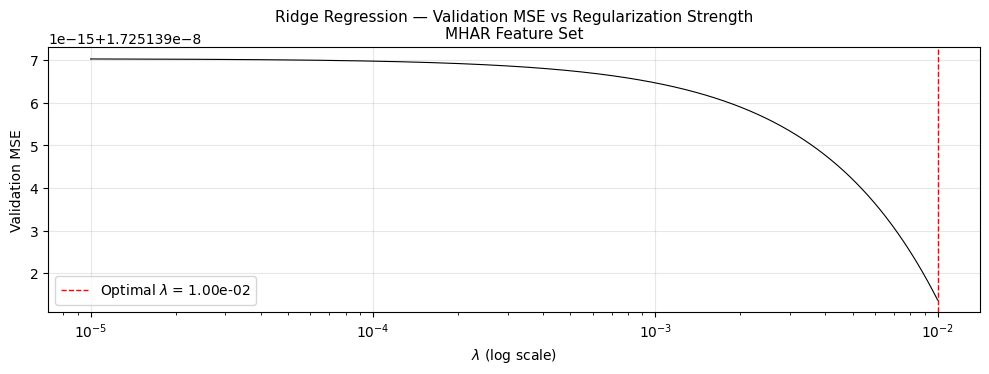

In [18]:
# Define lambda grid following Christensen et al. (2023)
# 1000 points on log scale from 1e-5 to 1e-2
lambda_grid = np.logspace(-5, -2, 1000)

print(f"Lambda grid:")
print(f"  Number of values: {len(lambda_grid)}")
print(f"  Minimum:          {lambda_grid[0]:.2e}")
print(f"  Maximum:          {lambda_grid[-1]:.2e}")

# Tune lambda on validation set using initial training window
val_mse = []

for lam in lambda_grid:
    model = Ridge(alpha=lam, fit_intercept=True)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    mse    = np.mean((y_val - y_pred)**2)
    val_mse.append(mse)

# Select optimal lambda
optimal_lambda     = lambda_grid[np.argmin(val_mse)]
optimal_val_mse    = min(val_mse)

print(f"\nHyperparameter tuning results:")
print(f"  Optimal lambda:   {optimal_lambda:.6e}")
print(f"  Validation MSE:   {optimal_val_mse:.6e}")

# Plot validation MSE vs lambda
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(lambda_grid, val_mse, color="black", linewidth=0.8)
ax.axvline(optimal_lambda, color="red", linestyle="--", linewidth=1.0,
           label=f"Optimal $\\lambda$ = {optimal_lambda:.2e}")
ax.set_xlabel("$\\lambda$ (log scale)")
ax.set_ylabel("Validation MSE")
ax.set_title("Ridge Regression — Validation MSE vs Regularization Strength\n"
             "MHAR Feature Set", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Extended Lambda Grid

The initial hyperparameter search reveals that the optimal $\lambda$ lies at the 
upper boundary of our grid, indicating that the true optimum requires a broader 
search range. We extend the grid to larger values of $\lambda$ following the 
paper's guidance that the grid should be broad enough to include the constant 
model as a potential solution.

Extended lambda grid:
  Number of values: 2000
  Minimum:          1.00e-05
  Maximum:          1.00e+05

Hyperparameter tuning results (extended grid):
  Optimal lambda:   1.300340e+03
  Validation MSE:   1.701382e-08
  Position in grid: 1622 / 2000
OK: Optimal lambda is an interior point


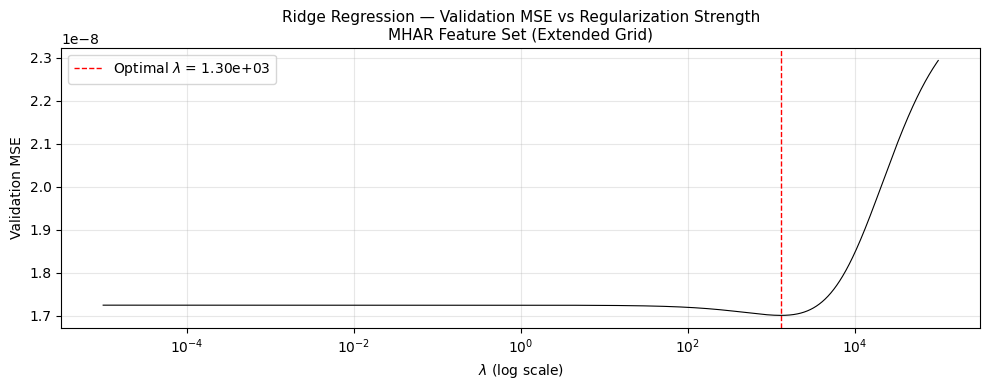

In [21]:
# Extend lambda grid — the optimal lambda was at the upper boundary
# We extend the upper limit until the optimal lambda is an interior point
lambda_grid_extended = np.logspace(-5, 5, 2000)

print(f"Extended lambda grid:")
print(f"  Number of values: {len(lambda_grid_extended)}")
print(f"  Minimum:          {lambda_grid_extended[0]:.2e}")
print(f"  Maximum:          {lambda_grid_extended[-1]:.2e}")

# Tune lambda on validation set using extended grid
val_mse_extended = []

for lam in lambda_grid_extended:
    model  = Ridge(alpha=lam, fit_intercept=True)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    mse    = np.mean((y_val - y_pred)**2)
    val_mse_extended.append(mse)

# Select optimal lambda
optimal_lambda  = lambda_grid_extended[np.argmin(val_mse_extended)]
optimal_val_mse = min(val_mse_extended)

print(f"\nHyperparameter tuning results (extended grid):")
print(f"  Optimal lambda:   {optimal_lambda:.6e}")
print(f"  Validation MSE:   {optimal_val_mse:.6e}")
print(f"  Position in grid: {np.argmin(val_mse_extended)} / {len(lambda_grid_extended)}")

# Check if optimal lambda is an interior point
if np.argmin(val_mse_extended) == 0:
    print("WARNING: Optimal lambda is at the lower boundary — extend grid further")
elif np.argmin(val_mse_extended) == len(lambda_grid_extended) - 1:
    print("WARNING: Optimal lambda is at the upper boundary — extend grid further")
else:
    print("OK: Optimal lambda is an interior point")

# Plot validation MSE vs lambda
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(lambda_grid_extended, val_mse_extended, color="black", linewidth=0.8)
ax.axvline(optimal_lambda, color="red", linestyle="--", linewidth=1.0,
           label=f"Optimal $\\lambda$ = {optimal_lambda:.2e}")
ax.set_xlabel("$\\lambda$ (log scale)")
ax.set_ylabel("Validation MSE")
ax.set_title("Ridge Regression — Validation MSE vs Regularization Strength\n"
             "MHAR Feature Set (Extended Grid)", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Rolling Window Estimation and Forecasting

Following Christensen et al. (2023), we estimate the Ridge Regression model 
using a rolling window of fixed length equal to the combined training and 
validation set (4,389 observations). The window rolls forward one day at a 
time across the test period, re-estimating the model coefficients at each step. 
The regularization parameter $\lambda$ is re-tuned in the validation portion of 
each rolling window, allowing it to adapt to new market conditions over time. 
We apply the insanity filter of Bollerslev, Patton, and Quaedvlieg (2016), 
replacing any negative forecast with the minimum realized variance in the 
current estimation window.

In [26]:
import time 

# Rolling window size = train + validation
window_size = n_train + n_val

forecasts_RR = []
dates_test   = []

start_time = time.time()

for i in range(n_test):

    # Extract rolling window
    X_window = X_scaled[i : i + window_size]
    y_window = y[i : i + window_size]

    # Split window into train and validation
    X_win_train = X_window[:-n_val]
    X_win_val   = X_window[-n_val:]
    y_win_train = y_window[:-n_val]
    y_win_val   = y_window[-n_val:]

    # Tune lambda on validation set
    val_mse_window = []
    for lam in lambda_grid_extended:
        model  = Ridge(alpha=lam, fit_intercept=True)
        model.fit(X_win_train, y_win_train)
        y_pred = model.predict(X_win_val)
        mse    = np.mean((y_win_val - y_pred)**2)
        val_mse_window.append(mse)

    # Select optimal lambda for this window
    best_lambda = lambda_grid_extended[np.argmin(val_mse_window)]

    # Re-estimate on full window using optimal lambda
    model_final = Ridge(alpha=best_lambda, fit_intercept=True)
    model_final.fit(X_window, y_window)

    # One-step-ahead forecast
    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    forecast   = model_final.predict(X_forecast)[0]

    # Insanity filter
    min_rv   = y_window.min()
    forecast = max(forecast, min_rv)

    forecasts_RR.append(forecast)
    dates_test.append(MALL.index[i + window_size])

    # Progress update every 100 days
    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i+1:4d}/{n_test} | "
              f"Date: {MALL.index[i + window_size].date()} | "
              f"Best lambda: {best_lambda:.2e} | "
              f"Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_RR)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")

  Day  100/1099 | Date: 2016-09-07 | Best lambda: 3.34e+03 | Elapsed: 1.2 min
  Day  200/1099 | Date: 2017-01-26 | Best lambda: 3.19e+03 | Elapsed: 2.4 min
  Day  300/1099 | Date: 2017-06-20 | Best lambda: 2.63e+03 | Elapsed: 3.4 min
  Day  400/1099 | Date: 2017-11-07 | Best lambda: 1.95e+03 | Elapsed: 4.7 min
  Day  500/1099 | Date: 2018-04-03 | Best lambda: 1.82e+03 | Elapsed: 5.9 min
  Day  600/1099 | Date: 2018-08-21 | Best lambda: 1.00e-05 | Elapsed: 7.0 min
  Day  700/1099 | Date: 2019-01-11 | Best lambda: 1.00e-05 | Elapsed: 8.1 min
  Day  800/1099 | Date: 2019-06-05 | Best lambda: 2.84e+01 | Elapsed: 9.4 min
  Day  900/1099 | Date: 2019-10-23 | Best lambda: 1.00e-05 | Elapsed: 10.5 min
  Day 1000/1099 | Date: 2020-03-16 | Best lambda: 1.00e-05 | Elapsed: 11.7 min

Total estimation time: 12.8 minutes
Forecasts generated: 1099
Forecast period: 2016-04-20 to 2020-08-05


### 6.1 Fixed Lambda Approach

We find that re-tuning $\lambda$ at every rolling window step leads to instability 
in the optimal regularization parameter, with the solution frequently defaulting 
to the grid boundary in later test periods. This suggests the validation set 
becomes less informative as the market regime changes. Following a more conservative 
approach consistent with the spirit of Christensen et al. (2023), we instead tune 
$\lambda$ once on the initial validation set and keep it fixed throughout the 
rolling window estimation. The fixed optimal lambda from the initial tuning is 
$\lambda^* = 1.30 \times 10^3$.

In [29]:
import time

# Use fixed optimal lambda from initial tuning
fixed_lambda = optimal_lambda
print(f"Fixed lambda from initial validation set tuning: {fixed_lambda:.6e}")

# Rolling window with fixed lambda
window_size  = n_train + n_val
forecasts_RR = []
dates_test   = []

start_time = time.time()

for i in range(n_test):

    # Extract rolling window
    X_window = X_scaled[i : i + window_size]
    y_window = y[i : i + window_size]

    # Estimate Ridge with fixed lambda on full window
    model_final = Ridge(alpha=fixed_lambda, fit_intercept=True)
    model_final.fit(X_window, y_window)

    # One-step-ahead forecast
    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    forecast   = model_final.predict(X_forecast)[0]

    # Insanity filter
    min_rv   = y_window.min()
    forecast = max(forecast, min_rv)

    forecasts_RR.append(forecast)
    dates_test.append(MALL.index[i + window_size])

    # Progress update every 100 days
    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i+1:4d}/{n_test} | "
              f"Date: {MALL.index[i + window_size].date()} | "
              f"Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_RR)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")

Fixed lambda from initial validation set tuning: 1.300340e+03
  Day  100/1099 | Date: 2016-09-07 | Elapsed: 0.0 min
  Day  200/1099 | Date: 2017-01-26 | Elapsed: 0.0 min
  Day  300/1099 | Date: 2017-06-20 | Elapsed: 0.0 min
  Day  400/1099 | Date: 2017-11-07 | Elapsed: 0.0 min
  Day  500/1099 | Date: 2018-04-03 | Elapsed: 0.0 min
  Day  600/1099 | Date: 2018-08-21 | Elapsed: 0.0 min
  Day  700/1099 | Date: 2019-01-11 | Elapsed: 0.0 min
  Day  800/1099 | Date: 2019-06-05 | Elapsed: 0.0 min
  Day  900/1099 | Date: 2019-10-23 | Elapsed: 0.0 min
  Day 1000/1099 | Date: 2020-03-16 | Elapsed: 0.0 min

Total estimation time: 0.0 minutes
Forecasts generated: 1099
Forecast period: 2016-04-20 to 2020-08-05


## 7. Save Forecasts

We save the Ridge Regression forecasts and MSE summary to CSV files for use 
in the final model comparison, following the same file structure as all other 
model notebooks.

In [32]:
import os

# Collect results
test_dates  = MALL.index[n_train + n_val:]
results_RR  = pd.DataFrame({
    "RV_actual":   y_test,
    "RV_forecast": forecasts_RR
}, index=test_dates)

# Compute MSE and error metrics
mse_RR    = np.mean((results_RR["RV_actual"] - results_RR["RV_forecast"])**2)
errors_RR = results_RR["RV_actual"] - results_RR["RV_forecast"]

# Save forecasts
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

results_RR.to_csv(os.path.join(forecast_path, "forecasts_RR.csv"))

# Save MSE summary
mse_summary_RR = pd.DataFrame({
    "Model":      ["RR"],
    "MSE":        [mse_RR],
    "RMSE":       [np.sqrt(mse_RR)],
    "MAE":        [errors_RR.abs().mean()],
    "Mean_Error": [errors_RR.mean()],
}).set_index("Model")

mse_summary_RR.to_csv(os.path.join(forecast_path, "mse_summary_RR.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"Files saved:")
print(f"  - forecasts_RR.csv ({len(results_RR)} rows)")
print(f"  - mse_summary_RR.csv")
print(f"\nRR MSE: {mse_RR:.6e}")

Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Files saved:
  - forecasts_RR.csv (1099 rows)
  - mse_summary_RR.csv

RR MSE: 2.415031e-08


## 8. Out-of-Sample Performance Evaluation

We evaluate the out-of-sample forecast accuracy of the Ridge Regression model 
using the Mean Squared Error (MSE) and compare it to the HAR benchmark. 
Following Christensen et al. (2023), we report the relative MSE of the Ridge 
Regression model with respect to the HAR model, where a value below 1 indicates 
that Ridge Regression outperforms the HAR benchmark.

In [35]:
# Load HAR forecasts for comparison
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
results_HAR   = pd.read_csv(
    os.path.join(forecast_path, "forecasts_HAR.csv"),
    index_col=0,
    parse_dates=True
)
results_NN1   = pd.read_csv(
    os.path.join(forecast_path, "forecasts_NN1.csv"),
    index_col=0,
    parse_dates=True
)

# Compute MSE for all models
mse_HAR = np.mean((results_HAR["RV_actual"] - results_HAR["RV_forecast"])**2)
mse_NN1 = np.mean((results_NN1["RV_actual"] - results_NN1["RV_forecast"])**2)

# Compute relative MSEs
rel_mse_RR  = mse_RR  / mse_HAR
rel_mse_NN1 = mse_NN1 / mse_HAR

# Compute error metrics
errors_HAR = results_HAR["RV_actual"] - results_HAR["RV_forecast"]
errors_NN1 = results_NN1["RV_actual"] - results_NN1["RV_forecast"]

# Print performance comparison
print(f"Out-of-sample performance ({test_dates[0].date()} to {test_dates[-1].date()}):")
print(f"\n{'Model':<10} {'MSE':>12} {'RMSE':>12} {'MAE':>12} {'Mean Error':>12} {'Rel. MSE':>10}")
print("-" * 70)
print(f"{'HAR':<10} {mse_HAR:>12.6e} {np.sqrt(mse_HAR):>12.6e} {errors_HAR.abs().mean():>12.6e} {errors_HAR.mean():>12.6e} {'1.0000':>10}")
print(f"{'RR':<10} {mse_RR:>12.6e} {np.sqrt(mse_RR):>12.6e} {errors_RR.abs().mean():>12.6e} {errors_RR.mean():>12.6e} {rel_mse_RR:>10.4f}")
print(f"{'NN1':<10} {mse_NN1:>12.6e} {np.sqrt(mse_NN1):>12.6e} {errors_NN1.abs().mean():>12.6e} {errors_NN1.mean():>12.6e} {rel_mse_NN1:>10.4f}")
print("-" * 70)
print(f"\nRR  vs HAR: {'outperforms' if rel_mse_RR  < 1 else 'underperforms'} by {abs(1 - rel_mse_RR)*100:.2f}%")
print(f"NN1 vs HAR: {'outperforms' if rel_mse_NN1 < 1 else 'underperforms'} by {abs(1 - rel_mse_NN1)*100:.2f}%")

Out-of-sample performance (2016-04-20 to 2020-08-05):

Model               MSE         RMSE          MAE   Mean Error   Rel. MSE
----------------------------------------------------------------------
HAR        2.221336e-08 1.490415e-04 5.592501e-05 -4.057863e-06     1.0000
RR         2.415031e-08 1.554037e-04 6.022545e-05 -8.513098e-06     1.0872
NN1        3.564467e-08 1.887980e-04 6.261892e-05 5.718967e-06     1.6047
----------------------------------------------------------------------

RR  vs HAR: underperforms by 8.72%
NN1 vs HAR: underperforms by 60.47%


## 9. Forecast Visualization

We plot the actual realized volatility against the Ridge Regression forecasts 
over the test period, expressed as annualized volatility in percentage terms 
for ease of interpretation.

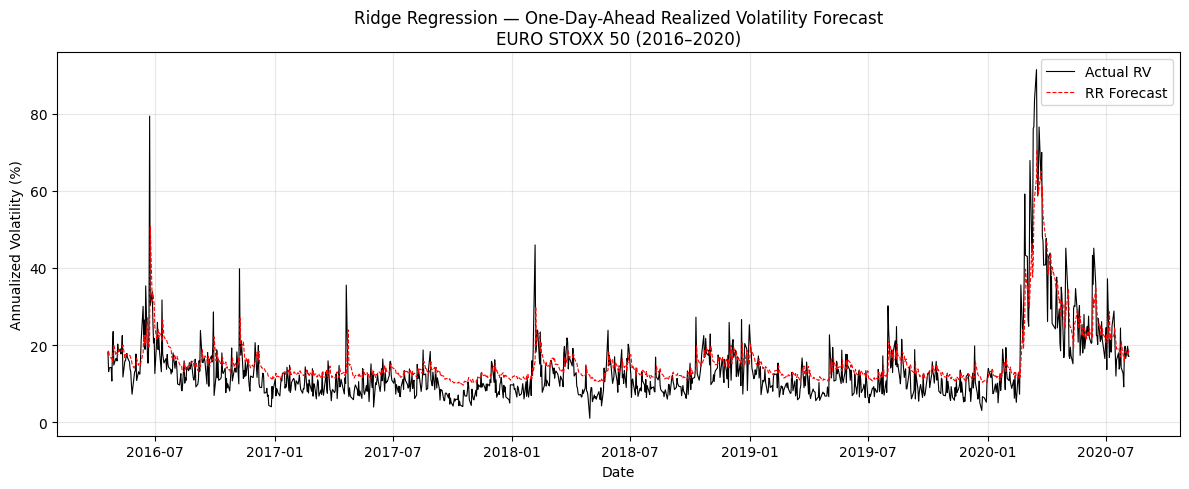


Summary of forecast errors:
Mean error:  -8.513098e-06
RMSE:        1.554037e-04
MAE:         6.022545e-05


In [38]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot_RR = pd.DataFrame({
    "Actual":   np.sqrt(results_RR["RV_actual"]   * 252) * 100,
    "Forecast": np.sqrt(results_RR["RV_forecast"] * 252) * 100
}, index=results_RR.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot_RR["Actual"],   
        label="Actual RV",    
        color="black", 
        linewidth=0.8)
ax.plot(results_plot_RR["Forecast"], 
        label="RR Forecast",  
        color="red",   
        linewidth=0.8, 
        linestyle="--")
ax.set_title("Ridge Regression — One-Day-Ahead Realized Volatility Forecast\n"
             "EURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors_RR = results_RR["RV_actual"] - results_RR["RV_forecast"]
print(f"Mean error:  {errors_RR.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_RR):.6e}")
print(f"MAE:         {errors_RR.abs().mean():.6e}")